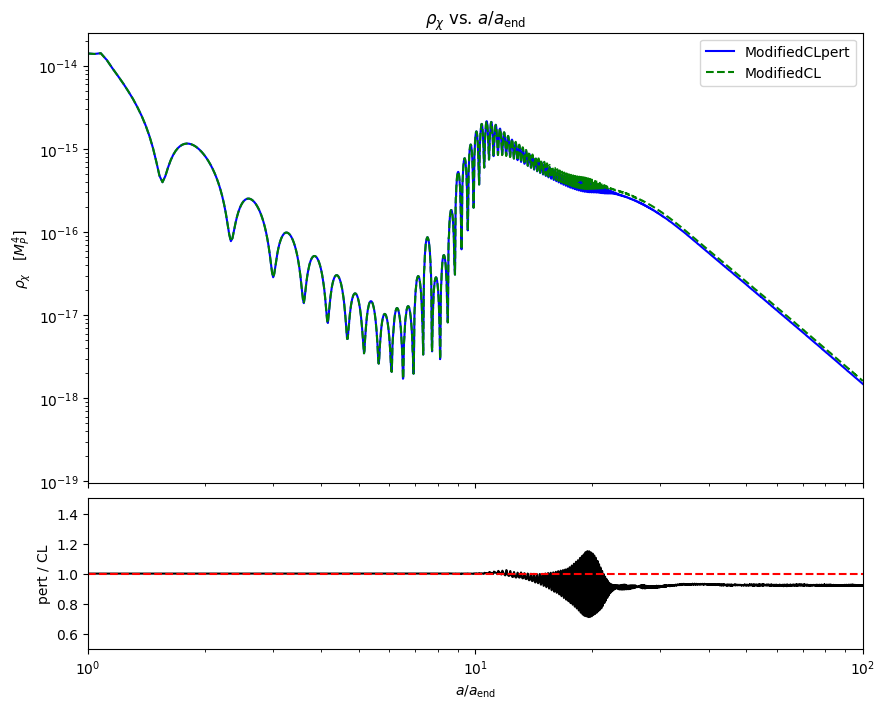

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.interpolate import UnivariateSpline, interp1d
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os

f_star = 2.0423e+18
M_p = 2.435e18
M = 5.964e18
Lambda4 = 8.648e63
omega_star =  np.sqrt(Lambda4 / M**2)

# -----------------------------
# File helper
# -----------------------------
def read_and_process_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    data = [list(map(float, line.split())) for line in lines]
    return list(zip(*data))  # columns

# -----------------------------
# Paths
# -----------------------------
pathpert = '../ModifiedCLOutput/tanh2/'
path     = '../CLOutput/tanh2/'

# -----------------------------
# Load both datasets
# -----------------------------
avg_energies_pert = read_and_process_file(pathpert + 'average_energies.txt')
avg_sf_pert       = read_and_process_file(pathpert + 'average_scale_factor.txt')

avg_energies_cl = read_and_process_file(path + 'average_energies.txt')
avg_sf_cl       = read_and_process_file(path + 'average_scale_factor.txt')

# -----------------------------
# Build rho_chi = column 3 + column 4
# -----------------------------
rho_chi_pert = (np.array(avg_energies_pert[3]) + np.array(avg_energies_pert[4])+ np.array(avg_energies_pert[6])) * f_star**2 * omega_star**2 / M_p**4
rho_chi_cl   = (np.array(avg_energies_cl[3])   + np.array(avg_energies_cl[4])  + np.array(avg_energies_cl[6])) * f_star**2 * omega_star**2 / M_p**4

# -----------------------------
# Second plot: rho_chi vs a/a_end
# -----------------------------
a_pert = np.array(avg_sf_pert[1])
a_cl   = np.array(avg_sf_cl[1])

cl_a_interp = interp1d(
    a_cl,
    rho_chi_cl,
    kind='linear',
    fill_value='extrapolate',
    bounds_error=False
)

rho_chi_cl_on_pert_a = cl_a_interp(a_pert)
ratio_a = rho_chi_pert / rho_chi_cl_on_pert_a

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax0 = plt.subplot(gs[0])
ax0.plot(a_pert, rho_chi_pert, label='ModifiedCLpert', color='blue')
ax0.plot(a_cl, rho_chi_cl, label='ModifiedCL', color='green', linestyle='--')
ax0.set_xlabel(r'$a/a_\text{end}$')
ax0.set_ylabel(r'$\rho_\chi\quad [M_P^4]$')
ax0.set_title(r'$\rho_\chi$ vs. $a/a_\text{end}$')
ax0.set_yscale('log')
ax0.set_xscale('log')
ax0.set_xlim(1, 1e2)
ax0.legend()
ax0.tick_params(labelbottom=False)

ax1 = plt.subplot(gs[1], sharex=ax0)
ax1.plot(a_pert, ratio_a, color='black')
ax1.axhline(1.0, color='red', linestyle='--')
ax1.set_xlabel(r'$a/a_\text{end}$')
ax1.set_ylabel(r'pert / CL')
ax1.set_xscale('log')
ax1.set_xlim(1, 1e2)
ax1.set_ylim(0.5,1.5)

plt.show()

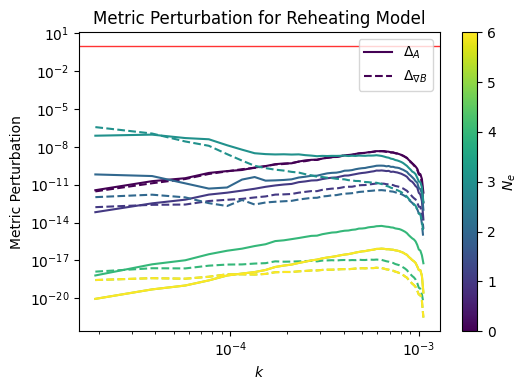

In [13]:
# Function to read blocks from the data file
def read_blocks(file_path):
    with open(file_path, 'r') as f:
        blocks = f.read().strip().split("\n\n")
    return [block.strip() for block in blocks]

# Function to read the times from the time file
def read_times(time_file_path):
    with open(time_file_path, 'r') as f:
        times = [float(line.strip()) for line in f.readlines()]
    return times

def process_block(block):
    data = [list(map(float, line.split())) for line in block.split("\n")]
    return list(zip(*data))  # Transpose to columns

avg_scalar = read_and_process_file(path + 'average_scalar_0.txt')
avg_sf = read_and_process_file(path + 'average_scale_factor.txt')
avg_energies = read_and_process_file(path + 'average_energies.txt')
avg_energies_conservation = read_and_process_file(path + 'average_energy_conservation.txt')
spectra_blocks = read_blocks(path + 'spectra_scalar_0.txt')
spectra_times = read_times(path + 'average_spectra_times.txt')

# Read scale factors and times then create interpolation
t = np.array(avg_sf[0])
a = np.array(avg_sf[1])
a_t = UnivariateSpline(t, a, s=0) # I use _t to denote, 'as a function of t'

# Read the Hubble then create interpolation
Hubble = np.array(avg_sf[3]) * omega_star/M_p
Hubble_t = UnivariateSpline(t,Hubble,s=0)

# Define horizon wavevector then create interpolation
kh = Hubble * a
kh_t = UnivariateSpline(t, kh, s=0)

# Read field velocity and times then create interpolation
phi = np.array(avg_scalar[1]) * f_star/M_p
phi_t = UnivariateSpline(t,phi,s=0)
dphi = np.array(avg_scalar[2]) * f_star * omega_star / M_p**2 # Time derivative is w.r.t. cosmic time
dphi_t = UnivariateSpline(t,dphi,s=0)
V = np.array(avg_energies[3]) * (f_star * omega_star)**2 / M_p**4
V_t = UnivariateSpline(t,V,s=0)
dV_t = UnivariateSpline(t,V,s=0).derivative

# Define epsilon
def epsilon_t(t):
    return 0.5 * dphi_t(t)**2 / (Hubble_t(t)**2)

ddphi_t_calc = dphi_t.derivative()

def ddphi_t(t):
    return ddphi_t_calc(t)  * omega_star / M_p

def eta_t(t):
    return -ddphi_t(t) / (Hubble_t(t) * dphi_t(t))

# Indices of the spectra blocks to plot
indices_to_plot = [i for i in range(0, int(len(spectra_blocks)/10), 1)]


# Indices / targets in Ne
target_Ne = [0, 1, 2, 3, 4, 5, 6]
current_Nes = np.array([np.log(a_t(t)) for t in spectra_times])

# Output folder for the saved metric-perturbation data
out_dir = "tanh2/"
os.makedirs(out_dir, exist_ok=True)

# Figure
fig, ax = plt.subplots(figsize=[5.5, 4])

# Color map by Ne
cmap = cm.viridis
norm = mcolors.Normalize(vmin=min(target_Ne), vmax=max(target_Ne))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for target in target_Ne:
    idx = np.abs(current_Nes - target).argmin()
    block = spectra_blocks[idx]
    x, y1, y2, y3 = process_block(block)

    # Use Mp consistently (you defined Mp above)
    k = np.array(x) * omega_star / M_p
    Deltaphi = np.array(y1) * f_star**2 / M_p**2
    Deltadphi = np.array(y2) * f_star**2 * omega_star**2 / M_p**4

    time = spectra_times[idx]
    eps = epsilon_t(time)
    H = Hubble_t(time)
    phidot = dphi_t(time)
    delta_sr = eta_t(time)

    DeltaA = (eps * H / phidot)**2 * Deltaphi
    DeltaB = (
        (eps * H / phidot)**2
        * (Deltadphi + (delta_sr - eps)**2 * H**2 * Deltaphi) / k**2
        
    )

    color = cmap(norm(target))
    ax.plot(k, DeltaA, color=color, linestyle='-',
            label=r'$\Delta_A$' if target == target_Ne[0] else None)
    ax.plot(k, DeltaB, color=color, linestyle='--',
            label=r'$\Delta_{\nabla B}$' if target == target_Ne[0] else None)

    # Save the data for this Ne snapshot
    save_data = np.column_stack([k, DeltaA, DeltaB])
    out_file = os.path.join(out_dir, f"MetricPerturbation_Ne{target}.txt")
    header = "k_over_Mp   abs_Ak   abs_kBk"
    np.savetxt(out_file, save_data, header=header)

#ax.axvspan(kh_t(0) - 1, kh_t(0), facecolor='grey', alpha=.3,
#           label="Initialised outside the horizon")
ax.axhline(1, color='r', linestyle='-', linewidth=1, alpha=0.8)

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'Metric Perturbation')
ax.set_title("Metric Perturbation for Reheating Model")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$N_e$')

plt.tight_layout()
plt.show()